In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib import font_manager
import seaborn as sns
import os
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import warnings
from datetime import datetime
date = datetime.today().strftime('%Y%m%d')
warnings.filterwarnings('ignore')
import re 

font_path = "C:\\Users\\User\\ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\Programs\\"
for f in font_manager.findSystemFonts(fontpaths=[font_path]):
    font_manager.fontManager.addfont(f)
plt.rcParams["font.family"] = "Inter"

In [2]:
METRICS = [
    "PI_Hg_OSAR", "Log2 Bout Speed ratio_Hg_OSAR",
    "Light Attraction Index_Hg_OSAR", "Bout Number Index_Hg_OSAR", "Bout Duration ratio_Hg_OSAR",
    "Max Velocity ratio_Hg_OSAR"
]

METRIC_DISPLAY = {
    "PI_Hg_OSAR": "PI", 
    "Log2 Bout Speed ratio_Hg_OSAR": "Log2 Bout Speed Ratio", "Light Attraction Index_Hg_OSAR": "Light Attraction Index",
    "Bout Number Index_Hg_OSAR": "Bout Number Index", "Bout Duration ratio_Hg_OSAR": "Bout Duration Ratio",
    "Max Velocity ratio_Hg_OSAR": "Max Velocity Ratio"
}

## Functions

In [3]:
def load_bootstrap_data(data_path, responders=None, metrics=None):
    metrics = metrics or METRICS
    all_data = {}
    
    for filename in [f for f in os.listdir(data_path) if f.endswith('_bootstrap.csv')]:
        parts = filename.replace('_bootstrap.csv', '').split(' x ')
        if len(parts) != 2: continue
        mbon, responder = parts
        if responders and responder not in responders: continue
        if responder not in all_data:
            all_data[responder] = {m: {} for m in metrics}
        
        df = pd.read_csv(os.path.join(data_path, filename))
        for (intensity, metric), group in df.groupby(['Light_Intensity', 'Metric']):
            if intensity == "Full" and metric in metrics:
                all_data[responder][metric][mbon] = {
                    'bootstrap': group['Bootstrap'].values,
                    'effect': group['Hedges_g'].iloc[0],
                    'ci_low': group['CI_low'].iloc[0],
                    'ci_high': group['CI_high'].iloc[0]
                }
    return all_data

def get_effect(data, responder, metric, mbon):
    d = data[responder][metric].get(mbon, {})
    return d.get('effect'), d.get('ci_low'), d.get('ci_high')

def get_bootstrap(data, responder, metric, mbon):
    return data[responder][metric].get(mbon, {}).get('bootstrap', np.zeros(5000))

def get_mbons(data, responder):
    mbons = set()
    for metric in data[responder]:
        mbons.update(data[responder][metric].keys())
    return list(mbons)

def get_mbons_by_number(data, responder, lobelocation):
    mbons = set()
    for metric in data[responder]:
        mbons.update(data[responder][metric].keys())
    
    if lobelocation is None or lobelocation.empty:
        return sorted(list(mbons))
    
    def sort_key(mbon):
        info = lobelocation[lobelocation['MBON'] == mbon]
        if len(info) > 0:
            match = re.search(r'(\d+)', str(info['MBON_number'].values[0]).strip())
            if match: return int(match.group(1))
        return 999
    return sorted(list(mbons), key=sort_key)

def find_number(df, lookup, col):
    vals = []
    for _, row in df.iterrows():
        if lookup in [x.strip() for x in row['MBON names'].split(',')]:
            vals.append(row[col])
    return ', '.join(list(set(vals)))

def create_labels(mbons, lobelocation, sep='\n'):
    if lobelocation is None or lobelocation.empty: return list(mbons)
    labels = []
    for mbon in mbons:
        info = lobelocation[lobelocation['MBON'] == mbon]
        if len(info) > 0:
            parts = [str(info['MBON_number'].values[0]), str(info['Lobe_location'].values[0]), mbon]
            labels.append(sep.join([p for p in parts if p and p != 'nan']) or mbon)
        else:
            labels.append(mbon)
    return labels

def _spiralize(fill, m, n):
    i, j, k = 0, 0, 0
    arr = np.zeros((m, n))
    while m > 0 and k < len(fill):
        jj, ii = j, i
        for j in range(j, n):
            if k >= len(fill): break
            arr[i,j] = fill[k]; k += 1
        for i in range(ii+1, m):
            if k >= len(fill): break
            arr[i,j] = fill[k]; k += 1
        for j in range(n-2, jj-1, -1):
            if k >= len(fill): break
            arr[i,j] = fill[k]; k += 1
        for i in range(m-2, ii, -1):
            if k >= len(fill): break
            arr[i,j] = fill[k]; k += 1
        m -= 1; n -= 1; j += 1
    return arr

def _sample_bootstrap(bootstrap, m, n, chop_tail=2.5):
    bs = sorted(bootstrap)
    chop = int(np.ceil(len(bs) * chop_tail / 100))
    bs = bs[chop:len(bs)-chop]
    ranks = np.linspace(0, len(bs), m*n, dtype=int)
    ranks[0] = 1
    if np.sum(np.array(bs) > 0) < len(bs)//2: bs = bs[::-1]
    return [bs[r-1] for r in ranks]

def _get_text_color(spirals, row_idx, col_idx, n, cmap, vmin, vmax):
    cy, cx = row_idx * n + n // 2, col_idx * n + n // 2
    center_val = np.mean(spirals[cy-1:cy+2, cx-1:cx+2])
    norm_val = np.clip((center_val - vmin) / (vmax - vmin), 0, 1) if vmax != vmin else 0.5
    cmap_obj = plt.get_cmap(cmap) if isinstance(cmap, str) else cmap
    rgba = cmap_obj(norm_val)
    luminance = 0.2126 * rgba[0] + 0.7152 * rgba[1] + 0.0722 * rgba[2]
    return 'white' if luminance < 0.5 else 'black'

def build_vortex_df(data, responder, metrics, lobelocation, n=11, chop_tail=2.5):
    mbons = get_mbons_by_number(data, responder, lobelocation)
    n_rows = len(mbons)
    n_cols = len(metrics)
    
    spirals = np.zeros((n_rows * n, n_cols * n))
    mean_vals = np.zeros((n_rows, n_cols))
    
    for i, mbon in enumerate(mbons):
        for j, metric in enumerate(metrics):
            bootstrap = get_bootstrap(data, responder, metric, mbon)
            sampled = _sample_bootstrap(bootstrap, n, n, chop_tail)
            spiral = _spiralize(sampled, n, n)
            spirals[i*n:(i+1)*n, j*n:(j+1)*n] = spiral
            effect, _, _ = get_effect(data, responder, metric, mbon)
            mean_vals[i, j] = effect if effect is not None else np.nan
    
    return spirals, mean_vals, mbons

def vortex_map(spirals, mean_vals, n=11, cmap='coolwarm', vmin=-1, vmax=1, 
               figsize=None, annot=True, annot_fontsize=9, annot_fmt='.2f'):
    n_rows, n_cols = mean_vals.shape
    
    fig, ax = plt.subplots(figsize=figsize or (n_cols * 1.5, n_rows * 0.6))
    ax.imshow(spirals, cmap=cmap, vmin=vmin, vmax=vmax, aspect='auto')
    
    # Remove spines (outer bounding box)
    for spine in ax.spines.values():
        spine.set_visible(False)
    
    if annot:
        for i in range(n_rows):
            for j in range(n_cols):
                color = _get_text_color(spirals, i, j, n, cmap, vmin, vmax)
                ax.text(j*n + (n-1)/2, i*n + (n-1)/2, f'{mean_vals[i,j]:{annot_fmt}}',
                        ha='center', va='center', fontsize=annot_fontsize, color=color)
    
    ax.set_xticks([j*n + (n-1)/2 for j in range(n_cols)])
    ax.set_yticks([i*n + (n-1)/2 for i in range(n_rows)])
    
    return fig, ax

## Code

In [4]:
data_path = r"C:\Users\User\ACC Lab Dropbox\ACC Lab\Nicole Lee\Data Compilation\osar_compiled\Bootstrapped stats"

responders = ["ACR", "Chrimson2"]
osar_data = load_bootstrap_data(data_path, responders=responders)
exclude = ['R76B09', 'VT999036']
[[osar_data[r][m].pop(key, None) for r in osar_data for m in osar_data[r] for key in exclude]];

In [16]:
responder = "ACR"

mbon_csv_path = r"C:\Users\User\ACC Lab Dropbox\ACC Lab\Nicole Lee\Data Compilation\MBONlist.csv"
lobelocation = pd.DataFrame()

csvfile = pd.read_csv(mbon_csv_path).astype('string')
# for n, k in zip(["B", "y", "a"], ['β', "γ", "α"]):
#     csvfile['Lobe'] = csvfile['Lobe'].str.replace(n, k)

mbons = get_mbons(osar_data, responder)
for m in mbons:
    row = {'MBON': m, 'Lobe_location': find_number(csvfile, m, "Lobe"),
            'MBON_number': find_number(csvfile, m, "MBON number").strip()}
    lobelocation = pd.concat([lobelocation, pd.DataFrame([row])])
lobelocation = lobelocation.reset_index(drop=True)

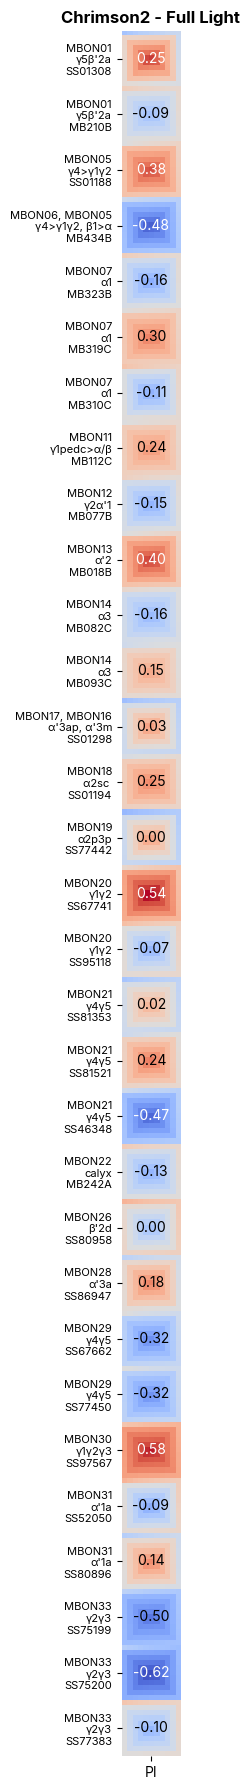

In [8]:
# Single metric
metrics_to_plot = ["PI_Hg_OSAR"]

spirals, mean_vals, mbons = build_vortex_df(osar_data, responder, metrics_to_plot, lobelocation)
fig, ax = vortex_map(spirals, mean_vals, cmap='coolwarm', vmin=-1, vmax=1,
                     figsize=(2, 18), annot=True, annot_fontsize=10)

ylabels = create_labels(mbons, lobelocation, sep='\n')
ax.set_yticklabels(ylabels, fontsize=8)
ax.set_xticklabels([METRIC_DISPLAY.get(m, m) for m in metrics_to_plot], fontsize=10)
ax.set_title(f"{responder} - Full Light", fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

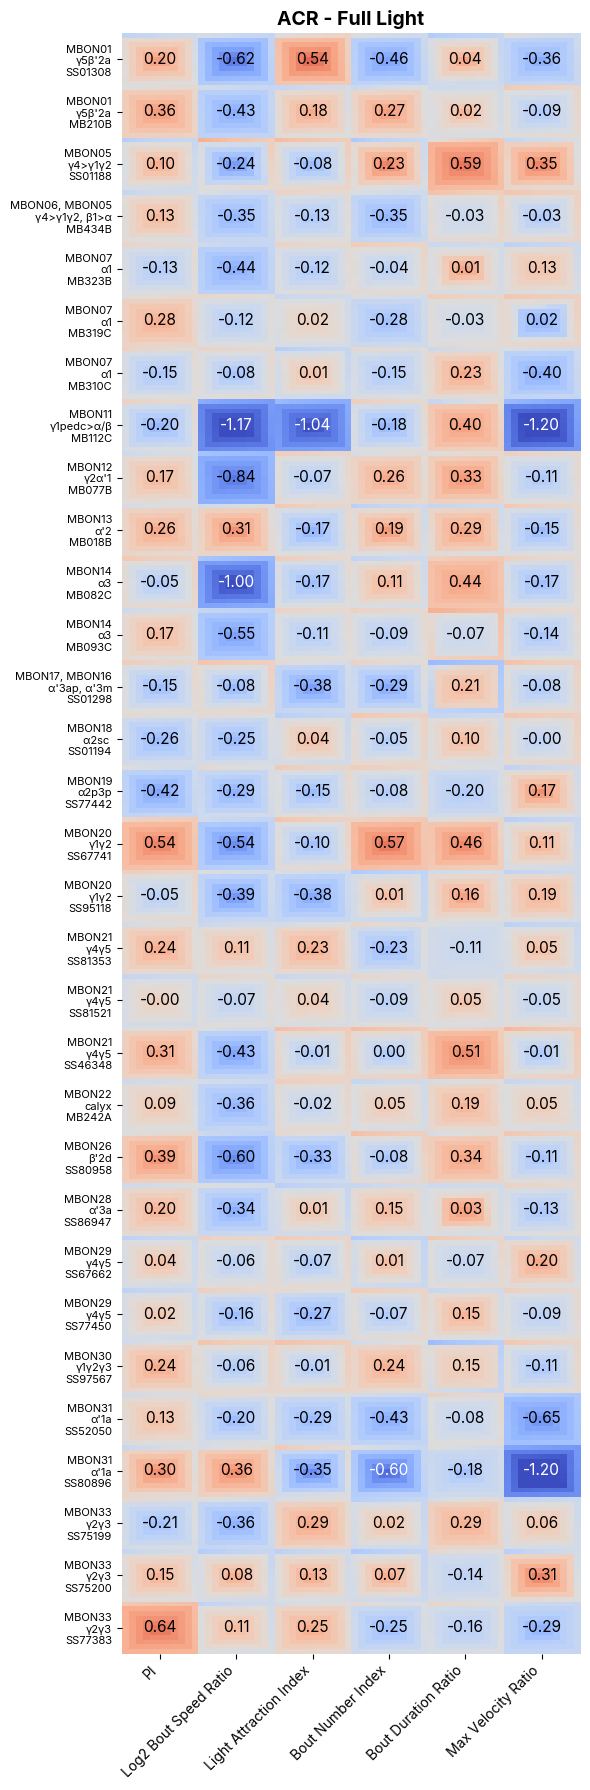

In [17]:
# All metrics in one heatmap
spirals, mean_vals, mbons = build_vortex_df(osar_data, responder, METRICS, lobelocation)
fig, ax = vortex_map(spirals, mean_vals, cmap='coolwarm', vmin=-1.5, vmax=1.5,
                     figsize=(6, 18), annot=True, annot_fontsize=11)

ylabels = create_labels(mbons, lobelocation, sep='\n')
ax.set_yticklabels(ylabels, fontsize=8)
ax.set_xticklabels([METRIC_DISPLAY.get(m, m) for m in METRICS], fontsize=10, rotation=45, ha='right')
ax.set_title(f"{responder} - Full Light", fontsize=14, fontweight='bold')


plt.tight_layout()
plt.show()